In [1]:
# ==========================================
# 1. PREPARACIÓ DE L'ENTORN MODERN
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

using ITensors
using ITensorMPS
using Plots

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


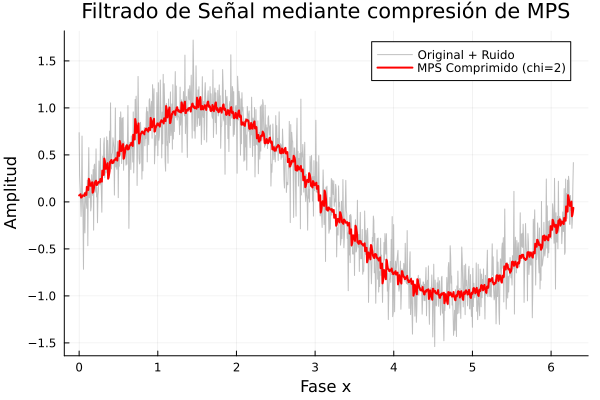

In [7]:
# Definición del número de sitios (n=10 para 2^10 = 1024 puntos)
n = 10
N = 2^n
sites = siteinds("Qubit", n)

# Generación de la señal con ruido
x = range(0, 2π, length=N)
signal = sin.(x) .+ 0.25 .* randn(N)

# Conversión del array denso a MPS mediante SVD sucesivas
# 'cutoff' define la precisión y 'maxdim' la bond dimension máxima inicial
mps = MPS(signal, sites; cutoff=1e-8)

# Compresión del MPS a chi=2
# Este proceso descarta los autovalores menos significativos (ruido)
mps_filtrat = truncate!(copy(mps); maxdim=2)

# Contracción
T = prod(mps_filtrat)

# Conversión a Array (esto genera un Array{Float64, 10})
filtrat_multidim = Array(T, sites)

# Aplanamiento (reshape a un vector de 1 dimensión)
# N es 2^n (1024), que ya lo definiste arriba
filtrat = reshape(filtrat_multidim, N)

# Configuración de la gráfica
p = plot(x, signal, 
    label="Original + Ruido", 
    linecolor=:gray, 
    alpha=0.5, 
    title="Filtrado de Señal mediante compresión de MPS")

plot!(p, x, filtrat, 
    label="MPS Comprimido (chi=2)", 
    linecolor=:red, 
    linewidth=2)

xlabel!("Fase x")
ylabel!("Amplitud")

# Para mostrar la gráfica
display(p)